### Run Multiple Calcium Wave Simulations on a Single Astrocyte - HEALTHY

Execute multiple calcium signaling simulations on a selected astrocyte morphology to quantify wave propagation dynamics, intracellular calcium activity, and signaling behavior across repeated trials.

#### Simulate Astrocyte Calcium and IP₃ Dynamics

1. Initialize astrocyte morphology, calcium stores, IP₃ concentrations, glutamate signaling, and diffusion parameters. 

2. Simulate intracellular calcium signaling, endoplasmic reticulum calcium exchange, membrane transport, and wave propagation over time. 

3. Store calcium activity maps, signaling metrics, and wave characteristics for downstream analysis and visualization.


 Initial Pixel Counts:
  Soma: 346 pixels (Label: 0)
  Thick Branches: 433 pixels (Label: 1)
  Thin Processes: 1767 pixels (Label: 2)
  Background: 9335 pixels (Label: 3)

 Running Simulation 1 / 1


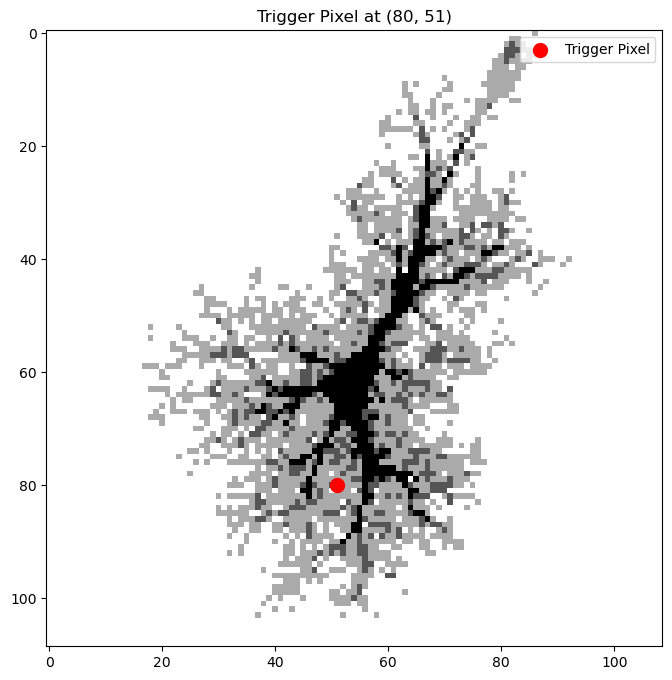

Step 0: J_SERCA mean: 5.77276, J_CICR mean: 9.43614, J_IP3R mean: 181.36140, J_leak mean: 0.06337
Triggering IP₃ at thin_process Pixel (80, 51)
Step 1000: J_SERCA mean: 9.29994, J_CICR mean: 7.03103, J_IP3R mean: 93.89525, J_leak mean: 0.05725
Step 2000: J_SERCA mean: 9.29993, J_CICR mean: 6.58693, J_IP3R mean: 89.07354, J_leak mean: 0.05283
Step 3000: J_SERCA mean: 9.29990, J_CICR mean: 6.18060, J_IP3R mean: 84.17494, J_leak mean: 0.04869
Step 4000: J_SERCA mean: 9.29986, J_CICR mean: 5.78268, J_IP3R mean: 79.74533, J_leak mean: 0.04480
Step 5000: J_SERCA mean: 9.29980, J_CICR mean: 5.39083, J_IP3R mean: 75.57387, J_leak mean: 0.04115
Step 6000: J_SERCA mean: 9.29971, J_CICR mean: 5.00804, J_IP3R mean: 71.67077, J_leak mean: 0.03771
Step 7000: J_SERCA mean: 9.29958, J_CICR mean: 4.63781, J_IP3R mean: 67.71057, J_leak mean: 0.03449
Step 8000: J_SERCA mean: 9.29936, J_CICR mean: 4.28289, J_IP3R mean: 63.87671, J_leak mean: 0.03148
Step 9000: J_SERCA mean: 9.29899, J_CICR mean: 3.94502, 

In [1]:
import torch
import time
import copy
import numpy as np
import cupy as cp
from cupyx.scipy.signal import convolve2d  # CuPy's equivalent of SciPy convolution
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
import json
import os

import astro_functions as af  # Import functions for calcium dynamics
import astro_preprocessing as ap 
import plot_utils_snapshots as pu

# ============================================================
# HIGH LEVEL PARAMETERS FOR THE SIM
# ============================================================
astro_file = "NPY_Files/Healthy_astro_1_stitched_rescaled.npy"
set_D_Ca = 0.7
set_D_ip3 = 25
num_simulations = 1
debug_mode = False  # Toggle debugging prints
introduce_noise = True

# ============================================================
# SETUP RESULTS DIRECTORY/FILES
# ============================================================
# Directory to store simulation results
results_dir = "astrocyte_wave_data"
astro_file_basename = os.path.splitext(os.path.basename(astro_file))[0]  # Extract filename without extension
astro_results_dir = os.path.join(results_dir, astro_file_basename)  # Subdirectory for this astrocyte
# Ensure directories exist
os.makedirs(astro_results_dir, exist_ok=True)
# Define result filenames
results_filename = os.path.join(astro_results_dir, f"{astro_file_basename}_wave_results.json")
simulation_results = [] 

# ============================================================
# LOAD IMAGE FILE
# ============================================================
segmented_data = np.load(astro_file)
# Load segmentation masks
(data, 
 soma_mask, 
 thick_branch_mask, 
 thin_process_mask, 
 background_mask, 
 soma_label, 
 thick_branch_label, 
 thin_process_label, 
 background_label) = ap.load_astrocyte_data(segmented_data)

# Ensure all loaded masks are CuPy arrays (if ap.load_astrocyte_data() returns NumPy arrays)
if isinstance(soma_mask, np.ndarray):
    soma_mask = cp.array(soma_mask)
    thick_branch_mask = cp.array(thick_branch_mask)
    thin_process_mask = cp.array(thin_process_mask)
    background_mask = cp.array(background_mask)

# ============================================================
# SIMULATION LOOP (Run 5 times)
# ============================================================
for sim_run in range(num_simulations):
    print(f"\n Running Simulation {sim_run + 1} / {num_simulations}")
    
    # ============================================================
    # PARAMETER SETTINGS
    # ============================================================
    ## Cytosolic Calcium Parameters
    Ca_rest, D_Ca, k_Ca, Ca_max = 0.12, set_D_Ca, 100, 10  # Lower k_Ca to slow decay
    Ca_soma, Ca_thick, Ca_thin = 0.4, 0.3, 0.3

    ## IP₃ Parameters
    ip3_rest, ip3_spike = 0.5, 0.5
    D_ip3, k_ip3 = set_D_ip3, 0.143 # Reduced decay rate to extend IP₃ activity
    ip3_soma, ip3_thick, ip3_thin = ip3_rest + 0.1, ip3_rest + 0.05, ip3_rest + 0.02

    hill_n_ip3 = 1.1  # Nonlinear decay exponent
    K_ip3 = 0.3  # Half-saturation constant for IP₃ degradation

    ## SERCA Uptake & ER Calcium Parameters
    Ca_ER_rest, Ca_ER_soma, Ca_ER_thick, Ca_ER_thin = 300.0, 250.0, 180.0, 90.0
    V_SERCA_soma, V_SERCA_thick, V_SERCA_thin = 6.2, 6.2, 6.2  # Tiny increase for faster ER storage

    #hill_n_ca = 2.5  # Nonlinear exponent for SERCA
    hill_n_ca = 3.5  # Nonlinear exponent for SERCA
    K_serca = 0.15  # Half-saturation constant

    ## IP₃R & CICR Activation (Ensure Flux Is Not Zero)
    k_IP3R_soma, k_IP3R_thick, k_IP3R_thin = 6.0, 2.2, 2.2  # Increased receptor sensitivity
    k_CICR_soma, k_CICR_thick, k_CICR_thin = 1.012, 0.2668, 0.2277 # Ensuring calcium-induced release

    K_IP3R, K_CICR, K_SERCA, K_inh, alpha = 0.2, 0.18, 0.5, 0.5, 0.012

    ## Glutamate Influence on IP₃ Production
    Glu_rest, Glu_spike = 0.1, 1.2
    gamma_Glu_base, gamma_Glu_amp, gamma_Glu_freq = 0.2, 0.1, 0.2  # Oscillation properties

    ## Buffer Properties
    B_total, k_on, k_off = 190.0, 0.3, 0.55  # Buffering properties

    ## Extracellular Calcium Pool
    Ca_ext_baseline = 1.5  # Baseline extracellular Ca²⁺ concentration

    ## Membrane Transport Constants
    PMCA_rate, NCX_rate, leak_rate = 2.0, 0.05, 0.002
    Na_in, Na_ext = 10, 130  # Intracellular & Extracellular Na⁺ levels
    Km_SOCE = 0.45  # SOCE activation threshold

    # Define oscillation parameters (if missing)
    oscillation_amplitude = 0.5  # Adjust as needed
    oscillation_frequency = 0.2  # Frequency in Hz
    baseline_ip3 = 0.1  # Ensure IP₃ doesn't drop too low

    ## Simulation Parameters
    num_steps, dt = 10000, 0.0001
    pixel_size_um = 0.2  # Spatial grid step
    time_values = cp.arange(num_steps) * dt
    trigger_steps = 100
    noise_level = np.random.uniform(0.005, 0.008)  # Random noise between .5% and .8%
    
    # ============================================================
    # INITIALIZATION
    # ============================================================
    ## Create Masks
    astro_mask = (data != background_label)
    rows, cols = segmented_data.shape 

    ## Initialize Cytosolic Calcium & Extracellular Calcium
    Ca_in = cp.full((rows, cols), Ca_rest)
    Ca_ext = cp.full_like(Ca_in, Ca_ext_baseline)  # Set extracellular Ca²⁺ to baseline (1.5 mM)
    Ca_ext = cp.maximum(Ca_ext, 1.2)  # Ensure extracellular Ca²⁺ doesn’t go below 1.2 mM
    Ca_ext = cp.minimum(Ca_ext, 2.0)  # Prevent extracellular Ca²⁺ from exceeding 2.0 mM

    ## Initialize Calcium Maps
    Ca_map = cp.full((rows, cols), Ca_rest)
    Ca_map = cp.maximum(Ca_map, 0)
    Ca_map = cp.minimum(cp.maximum(Ca_map, 0.1), 1.5)  # Slightly increase upper bound for more realistic variation
    Ca_map[soma_mask], Ca_map[thick_branch_mask], Ca_map[thin_process_mask] = Ca_soma, Ca_thick, Ca_thin
    if introduce_noise:
        Ca_map += noise_level * Ca_map * cp.random.randn(*Ca_map.shape)

    Ca_ER_map = cp.full((rows, cols), Ca_ER_rest)
    Ca_ER_map = cp.maximum(Ca_ER_map, 10.0)  # Prevents negative ER Ca²⁺
    Ca_ER_map = cp.minimum(Ca_ER_map, Ca_ER_rest)  # Prevents unrealistic ER overfilling
    Ca_ER_map[thin_process_mask], Ca_ER_map[thick_branch_mask], Ca_ER_map[soma_mask] = Ca_ER_thin, Ca_ER_thick, Ca_ER_soma

    ## Initialize IP₃ Map
    ip3_map = cp.full((rows, cols), ip3_rest)
    ip3_map = cp.minimum(ip3_map, 5.0)
    ip3_map[soma_mask], ip3_map[thick_branch_mask], ip3_map[thin_process_mask] = ip3_soma, ip3_thick, ip3_thin
    if introduce_noise:
        ip3_map += noise_level * ip3_map * cp.random.randn(*ip3_map.shape)
        
    ## Initialize Glutamate Map
    Glu_map = cp.full((rows, cols), Glu_rest)
    Glu_map[soma_mask] = Glu_spike  # Simulating synaptic glutamate release
    if introduce_noise:
        Glu_map += noise_level * Glu_map * cp.random.randn(*Glu_map.shape)
        
    ## Laplacian Kernel for Diffusion
    laplacian_kernel = cp.array([[0, 1, 0],
                                [1, -4, 1],
                                [0, 1, 0]])

    ## Initialize Calcium Buffering
    CaB_map = cp.zeros_like(Ca_map)  # Initially, no bound buffer
    
    if debug_mode and introduce_noise:
        print(f"Before Clipping: Ca²⁺ min = {Ca_map.min()}, max = {Ca_map.max()}")
        print(f"Before Clipping: IP₃ min = {ip3_map.min()}, max = {ip3_map.max()}")
        print(f"Before Clipping: Glu min = {Glu_map.min()}, max = {Glu_map.max()}")

    Ca_map = cp.clip(Ca_map, 0, Ca_max)
    ip3_map = cp.clip(ip3_map, 0, 5.0)
    Glu_map = cp.clip(Glu_map, 0, 2.0)
    
    if debug_mode and introduce_noise:
        print(f"After Clipping: Ca²⁺ min = {Ca_map.min()}, max = {Ca_map.max()}")
        print(f"After Clipping: IP₃ min = {ip3_map.min()}, max = {ip3_map.max()}")
        print(f"After Clipping: Glu min = {Glu_map.min()}, max = {Glu_map.max()}")

    ## Find Trigger and Tracking Pixels Dynamically
    trigger_region = "thin_process"  # Options: "soma", "thick_branch", "thin_process"
    
    if sim_run == 0: trigger_pixel = (80, 51)
        
    # Show the selected trigger pixel
    ap.show_trigger_pixel(segmented_data, trigger_pixel)

    # Select tracking pixels for different regions (printed separately)
    tracked_pixels = {
        "soma": ap.find_region_pixel(region="soma", 
                                soma_mask=soma_mask, 
                                thick_branch_mask=thick_branch_mask, 
                                thin_process_mask=thin_process_mask, 
                                label="Tracking Pixel",
                                debug_mode=debug_mode),
        
        "thick_branch": ap.find_region_pixel(region="thick_branch", 
                                soma_mask=soma_mask, 
                                thick_branch_mask=thick_branch_mask, 
                                thin_process_mask=thin_process_mask, 
                                label="Tracking Pixel",
                                debug_mode=debug_mode),

        "thin_process": ap.find_region_pixel(region="thin_process", 
                                soma_mask=soma_mask, 
                                thick_branch_mask=thick_branch_mask, 
                                thin_process_mask=thin_process_mask, 
                                label="Tracking Pixel",
                                debug_mode=debug_mode),
    }
    # ============================================================
    # STORAGE ARRAYS
    # ============================================================
    ## Choose Storage Method (All Timesteps vs. Snapshot Intervals)
    snapshot_interval = 10  # Save every 10 steps

    Ca_map_history = cp.zeros((num_steps // snapshot_interval, rows, cols))
    ip3_map_history = cp.zeros((num_steps // snapshot_interval, rows, cols))
    tracked_ER_Ca = {key: cp.zeros(num_steps) for key in tracked_pixels}

    total_ER_Ca_over_time = cp.zeros(num_steps // snapshot_interval)
    total_ip3_over_time = cp.zeros(num_steps // snapshot_interval)
    total_Glu_over_time = cp.zeros(num_steps // snapshot_interval)

    J_SERCA_store = cp.zeros(num_steps // snapshot_interval)
    J_CICR_store = cp.zeros(num_steps // snapshot_interval)
    J_IP3R_store = cp.zeros(num_steps // snapshot_interval)
    J_SOCE_store = cp.zeros(num_steps // snapshot_interval)
    J_PM_leak_store = cp.zeros(num_steps // snapshot_interval)
    J_pulsatile_IP3_store = cp.zeros(num_steps // snapshot_interval)
    num_changed_pixels = cp.zeros(num_steps // snapshot_interval)

    ## Storage for Debugging
    J_SERCA_list, J_CICR_list, J_IP3R_list, J_PM_leak_list, J_pulsatile_IP3_list = [], [], [], [], []

    ## Storage for Tracking Specific Pixel Values
    tracked_values = {key: {"Ca_cytosol": [], "Ca_ER": [], "IP3": [], "SOCE": [], "J_IP3R": [], "J_CICR": []} for key in tracked_pixels}

    # ============================================================
    # MAIN SIMULATION LOOP
    # ============================================================
    torch.cuda.synchronize()
    start = time.time()
    
    if debug_mode:
        print("===== DEBUG: Parameter Check Before Simulation Starts =====")
        print(f"NCX_rate: {NCX_rate}")
        print(f"PMCA_rate: {PMCA_rate}")
        print(f"V_SERCA_soma: {V_SERCA_soma}, V_SERCA_thick: {V_SERCA_thick}, V_SERCA_thin: {V_SERCA_thin}")
        print(f"Alpha (SERCA Boost): {alpha}")
        print(f"Total Buffer (B_total): {B_total}")
        print(f"Buffer On Rate (k_on): {k_on}")
        print(f"Buffer Off Rate (k_off): {k_off}")
        print(f"Bound Buffer Ratio (k_on / k_off): {k_on / k_off}")
        print("==========================================================")

    for t_idx, t in enumerate(time_values):
    
        # Precompute the padded version (so it’s not recomputed every iteration)
        ip3_map_padded = cp.pad(ip3_map, pad_width=1, mode='constant', constant_values=0)
        Ca_map_padded = cp.pad(Ca_map, pad_width=1, mode='constant', constant_values=0)
        # IP₃ TRIGGERING
        if t_idx == trigger_steps:
            print(f"Triggering IP₃ at {trigger_region} Pixel {trigger_pixel}")
            ip3_map[trigger_pixel] = ip3_spike  # Ensure spike is applied
        
        # COMPUTE OSCILLATORY MODULATION
        sin_value = cp.sin(2 * cp.pi * oscillation_frequency * t)
        
        # UPDATE GLUTAMATE-DEPENDENT FACTORS
        gamma_Glu = gamma_Glu_base + gamma_Glu_amp * cp.sin(2 * cp.pi * gamma_Glu_freq * time_values[t_idx])

        # PASSIVE EXTRACELLULAR LEAK (FIXED SIGN)
        Ca_flux_leak = -leak_rate * (Ca_ext - Ca_ext_baseline)  # Leak reduces Ca_ext
        Ca_ext = cp.maximum(Ca_ext + Ca_flux_leak, 0.5)  # Prevents negative values

        # UPDATE IP₃ PRODUCTION (WITH MAX LIMIT)
        ip3_map[soma_mask] = cp.minimum(ip3_map[soma_mask] + (0.005 * Ca_map[soma_mask]) * dt, ip3_spike)
        ip3_map[thick_branch_mask] = cp.minimum(ip3_map[thick_branch_mask] + (0.01 * Ca_map[thick_branch_mask]) * dt, ip3_spike)
        ip3_map[thin_process_mask] = cp.minimum(ip3_map[thin_process_mask] + (0.002 * Ca_map[thin_process_mask]) * dt, ip3_spike)

        # CREATE A COPY OF Ca_map (PREVENTS UNINTENDED MODIFICATIONS)
        prev_Ca_map = Ca_map.copy()

        # Get astrocyte region values
        Ca_val = Ca_map[astro_mask]
        Ca_ER_val = Ca_ER_map[astro_mask]
        ip3_val = ip3_map[astro_mask]

        # Compute free buffer concentration (only where needed)
        B_free = B_total - CaB_map[astro_mask]
        # Compute binding only where buffer is available
        CaB_binding = k_on * Ca_val * B_free - k_off * CaB_map[astro_mask]
        # Apply update only to valid pixels
        Ca_map[astro_mask] -= (CaB_binding * dt) * (B_free > 0)

        # ============================================================
        # IP3 DYNAMICS
        # ============================================================
        # 1. IP₃ Production & Degradation
        
        ip3_decay = k_ip3 * (ip3_map ** hill_n_ip3) / (K_ip3 ** hill_n_ip3 + ip3_map ** hill_n_ip3) * dt
        ip3_decay = cp.minimum(ip3_map, ip3_decay)  # Prevent negative IP₃ values
        
        # 2. Update IP₃ based on Ca²⁺ & Glutamate levels
        ip3_map += (0.1 * Glu_map * gamma_Glu * dt) + (0.0002 * Ca_map) - ip3_decay
        
        # 3. Stochastic & Oscillatory Modulation
        poisson_spike = cp.random.poisson(0.1, size=ip3_map.shape)  # Generate for all pixels at once
        ip3_oscillation = sin_value * cp.exp(-t_idx / 1000)  # Compute oscillation decay
        ip3_map += (poisson_spike * 0.05) + ip3_oscillation
        
        # 4. Ensure IP₃ remains above the baseline
        ip3_map = cp.maximum(ip3_map, baseline_ip3)
        
        # 5. IP₃ Diffusion Term 
        lap_IP3 = convolve2d(ip3_map_padded, laplacian_kernel, mode="valid") # Compute Laplacian for IP₃ diffusion using CuPy's convolve2d()
        diffusion_IP3 = (D_ip3 * lap_IP3 * dt) / (pixel_size_um ** 2)
        ip3_map += diffusion_IP3  # Apply diffusion update
        
        # 6. Apply Pulsatile IP₃ Stimulation AFTER Diffusion
        J_pulsatile_IP3 = 0.0005 * cp.sin(2 * cp.pi * t_idx / num_steps)
        ip3_map += J_pulsatile_IP3 * dt  # Apply to all pixels at once
        
        # ============================================================
        # GLUTAMATE DYNAMICS
        # ============================================================

        # Glutamate release scales with IP₃ and Ca²⁺ activity
        Glu_release = 0.02 * ip3_map * (Ca_map / (Ca_map + 1)) * dt  # Ensures nonlinear response
        Glu_map += Glu_release  # Increase glutamate levels based on astrocyte activation

        # Glutamate decay (astrocytic and synaptic uptake)
        Glu_decay = 0.005 * Glu_map * dt  # Decay at 0.5% per timestep
        Glu_map -= Glu_decay

        # Ensure Glutamate remains non-negative
        Glu_map = cp.maximum(Glu_map, 0)  # Prevents negative values

        # ============================================================
        # CA DYNAMICS
        # ============================================================ 
        # Enable "Fast Clearance Mode" when Ca²⁺ is high
        fast_clearance = cp.where(Ca_map > 0.5, 1.5, 1.0)  # Boosts clearance at high Ca²⁺
    
        # 1. SERCA Update BEFORE ER Leak & Release
        J_SERCA = (V_SERCA_soma * (Ca_map ** 5)) / (K_serca ** 4.5 + Ca_map ** 5)
        J_SERCA *= fast_clearance  # Apply fast clearance scaling

        # 2. ER Fluxes (Release & Uptake)
        J_IP3R = af.compute_J_IP3R(ip3_map, Ca_map, Ca_ER_map, k_IP3R_soma * 2.0, K_IP3R * 2.0, 3, K_inh, 3)
        J_CICR = af.compute_J_CICR(Ca_map, Ca_ER_map, k_CICR_soma * 1.6, K_CICR * 0.5)
        J_leak = 0.0005 * (Ca_ER_map - Ca_map)  # Reduce ER leak

        if t_idx % 1000 == 0:  # Print every 1000 timesteps
            print(f"Step {t_idx}: J_SERCA mean: {cp.mean(J_SERCA[astro_mask]).item():.5f}, "
                f"J_CICR mean: {cp.mean(J_CICR[astro_mask]).item():.5f}, "
                f"J_IP3R mean: {cp.mean(J_IP3R[astro_mask]).item():.5f}, "
                f"J_leak mean: {cp.mean(J_leak[astro_mask]).item():.5f}")
        
        # ============================================================
        # ADD NOISE TO FLUXES EVERY 100 STEPS
        # ============================================================
        if t_idx % 500 == 0 and introduce_noise:  # Apply noise every 500 time steps
            noise_factor = np.random.uniform(0.005, 0.008)
            J_SERCA += noise_factor * J_SERCA * cp.random.randn(*J_SERCA.shape)
            J_IP3R += noise_factor * J_IP3R * cp.random.randn(*J_IP3R.shape)
            J_CICR += noise_factor * J_CICR * cp.random.randn(*J_CICR.shape)
            J_leak += noise_factor * J_leak * cp.random.randn(*J_leak.shape)

        # Ensure values remain non-negative
        J_CICR = cp.maximum(J_CICR, 0)
        J_IP3R = cp.maximum(J_IP3R, 0)
        J_SERCA = cp.maximum(J_SERCA, 0)
        J_leak = cp.maximum(J_leak, 0)
        
        J_total_ER_to_Cytosol = J_IP3R + J_CICR + J_leak
        Ca_ER_map -= dt * (J_total_ER_to_Cytosol - J_SERCA)
        
        # 3. Store-Operated Ca²⁺ Entry (SOCE)
        J_SOCE = 0.004 * (1.0 - (Ca_ER_map / Ca_ER_rest))
        if t_idx % 500 == 0 and introduce_noise:  # Apply noise every 100 time steps
            J_SOCE += noise_factor * J_SOCE * cp.random.randn(*J_SOCE.shape)
        J_SOCE = cp.maximum(J_SOCE, 0)
        Ca_in += J_SOCE * dt  # Increase cytosolic Ca²⁺
        
        # 4. Update Extracellular Ca²⁺ based on SOCE feedback
        J_SOCE_ext = (0.15 * cp.abs(Ca_ext - 1.5)) / (Km_SOCE + cp.abs(Ca_ext - 1.5))  # More Ca²⁺ uptake if extracellular levels are high
        Ca_in += J_SOCE_ext * dt  # Apply to all pixels in one step
        
        # 5. Compute Membrane Transport (PMCA, NCX) AFTER SOCE is Applied
        Ca_flux_PMCA = (PMCA_rate * Ca_in**5) / (0.005 + Ca_in**5)
        Ca_flux_PMCA *= fast_clearance
        Ca_flux_NCX = NCX_rate * (((Ca_in ** 1.5) / (Ca_ext ** 1.5)) - (Na_ext**3 / Na_in**3))

        # 6. Apply Membrane Exchange
        Ca_in -= (Ca_flux_PMCA + Ca_flux_NCX)  # Apply both exports at once

        # 7. Spatial Diffusion for Ca²⁺ (Using Precomputed Convolution)
        lap_Ca = convolve2d(Ca_map_padded, laplacian_kernel, mode="valid")  # Compute Laplacian
        diffusion_Ca = (D_Ca * lap_Ca * dt) / (pixel_size_um ** 2)  # Compute diffusion update
        Ca_map += diffusion_Ca  # Apply diffusion update in one step
        
        # 8. Update Cytosolic Ca²⁺ (Before Diffusion)
        J_PM_leak = 0.002  # Passive Ca²⁺ leak from membrane
        #Ca_map += dt * (J_total_ER_to_Cytosol - J_SERCA + J_SOCE + J_PM_leak) + diffusion_Ca  # Final update
        Ca_map += dt * (J_total_ER_to_Cytosol - 1.5 * J_SERCA + J_SOCE * 0.5 + J_PM_leak * 0.5) + 0.5 * diffusion_Ca

        # 9. EXTRACELLULAR CALCIUM UPDATE (EVERY SNAPSHOT INTERVAL)
        if t_idx > 0 and t_idx % snapshot_interval == 0:
            num_skipped_steps = snapshot_interval  # Accumulate over skipped steps
            Ca_ext += num_skipped_steps * (Ca_flux_leak - J_SOCE_ext * dt + Ca_flux_PMCA + Ca_flux_NCX)
            # Ensure Ca_ext does not drop below 0.5 * baseline (element-wise CuPy operation)
            Ca_ext = cp.maximum(Ca_ext, Ca_ext_baseline * 0.5)

        # 10. Neumann Boundary Condition (No-Flux)
        Ca_ext[0, :] = Ca_ext[1, :]
        Ca_ext[-1, :] = Ca_ext[-2, :]
        Ca_ext[:, 0] = Ca_ext[:, 1]
        Ca_ext[:, -1] = Ca_ext[:, -2]

        # ============================================================
        # STORE TRACKED VALUES (Vectorized)
        # ============================================================
        # Store ER Ca²⁺ values in a single vectorized step
        for region, (ri, rj) in tracked_pixels.items():
            tracked_ER_Ca[region][t_idx] = Ca_ER_map[ri, rj]

        # Store Key Pixels' Dynamics
        for region, (ri, rj) in tracked_pixels.items():
            tracked_values[region]["Ca_cytosol"].append(Ca_map[ri, rj])
            tracked_values[region]["Ca_ER"].append(Ca_ER_map[ri, rj])
            tracked_values[region]["IP3"].append(ip3_map[ri, rj])
            tracked_values[region]["SOCE"].append(J_SOCE[ri, rj])
            tracked_values[region]["J_IP3R"].append(J_IP3R[ri, rj])
            tracked_values[region]["J_CICR"].append(J_CICR[ri, rj])

        # ============================================================
        # STORE DATA AT SNAPSHOT INTERVALS
        # ============================================================
        if t_idx % snapshot_interval == 0:
            # Store history with explicit CuPy copy (ensures memory efficiency)
            Ca_map_history[t_idx // snapshot_interval] = Ca_map.astype(cp.float32).copy()
            ip3_map_history[t_idx // snapshot_interval] = ip3_map.astype(cp.float32).copy()

            # Store total values efficiently
            total_ER_Ca_over_time[t_idx // snapshot_interval] = cp.sum(Ca_ER_map[astro_mask])
            total_ip3_over_time[t_idx // snapshot_interval] = cp.sum(ip3_map[astro_mask])
            total_Glu_over_time[t_idx // snapshot_interval] = cp.sum(Glu_map[astro_mask])
            
            if debug_mode:
                print(f"DEBUG: t_idx={t_idx}, IP3 sum = {total_ip3_over_time[t_idx // snapshot_interval].get():.5f}")

            # Store flux values directly
            J_SERCA_store[t_idx // snapshot_interval] = cp.mean(J_SERCA[astro_mask])  # CuPy array
            J_CICR_store[t_idx // snapshot_interval] = cp.mean(J_CICR[astro_mask])    # CuPy array
            J_IP3R_store[t_idx // snapshot_interval] = cp.mean(J_IP3R[astro_mask])    # CuPy array
            J_SOCE_store[t_idx // snapshot_interval] = cp.mean(J_SOCE[astro_mask])

            # Directly store scalar values (no need for cp.mean)
            J_PM_leak_store[t_idx // snapshot_interval] = J_PM_leak  # Already a float
            J_pulsatile_IP3_store[t_idx // snapshot_interval] = J_pulsatile_IP3  # Already a float

            # Track number of changed pixels efficiently
            num_changed_pixels[t_idx // snapshot_interval] = cp.sum(cp.abs(Ca_map - prev_Ca_map) > 0.01)

            # ============================================================
            # DEBUG PRINT
            # ============================================================
            if t_idx % 1000 == 0 and debug_mode:
                print(f"Step {t_idx}: Ca_ext at soma {Ca_ext[soma_mask].mean().item():.3f}, "
                    f"Ca_ext at periphery {Ca_ext[thin_process_mask].mean().item():.3f}")
                print(f"Step {t_idx}: Mean Ca_ER: {Ca_ER_map[astro_mask].mean().item():.3f}")
                print(f"Step {t_idx}: Total Glutamate Stored = {total_Glu_over_time[t_idx // snapshot_interval].item():.5f}")
                print(f"Step {t_idx}: Mean Glutamate = {cp.mean(Glu_map[astro_mask]).item():.5f}, Max Glutamate = {cp.max(Glu_map).item():.5f}")
                print(f"Step {t_idx}: Mean Bound Ca²⁺ Buffer: {cp.mean(CaB_map).item():.5f}")
                
        np.save(os.path.join(astro_results_dir, f"ER_Ca_run_{sim_run + 1}.npy"), total_ER_Ca_over_time.get())
        np.save(os.path.join(astro_results_dir, f"IP3_run_{sim_run + 1}.npy"), total_ip3_over_time.get())
        np.save(os.path.join(astro_results_dir, f"Glu_run_{sim_run + 1}.npy"), total_Glu_over_time.get())
        
        torch.cuda.synchronize()  # Ensure all GPU tasks finish before stopping timer
        end = time.time()

    # ============================================================
    # SAVE CALCIUM & IP₃ HISTORY DIRECTLY FROM GPU MEMORY
    # ============================================================
    cp.save("Ca_map_history.npy", Ca_map_history)
    cp.save("IP3_map_history.npy", ip3_map_history)
    cp.save("Total_ER_Ca_over_time.npy", total_ER_Ca_over_time)
    cp.save("Total_GLU_over_time.npy", total_Glu_over_time)

    # Compute wave speed, decay constants, and wave propagation distance
    wave_speed = pu.compute_ca_wave_speed(Ca_map_history, mask_filename=astro_file, pixel_size_um=0.2, dt=0.0001)
    wave_distance = pu.measure_wave_propagation(Ca_map_history, segmented_data, trigger_pixel, astro_mask, pixel_size_um=0.2)
    tau_ip3 = pu.compute_ip3_decay_constant(ip3_map_history, astro_mask, dt=0.001)
    tau_ca = pu.compute_ca_time_decay_constant(Ca_map_history, mask_filename=astro_file, dt=0.001)

    # Store results
    simulation_results.append({
        "run": sim_run + 1,
        "trigger_pixel": trigger_pixel,
        "wave_speed": wave_speed,
        "wave_distance": wave_distance,
        "tau_ip3": tau_ip3,
        "tau_ca": tau_ca
    })

    print(f"Run {sim_run + 1} Results: Wave Speed = {wave_speed:.2f} μm/s, Wave Distance = {wave_distance:.2f} μm, IP₃ Decay = {tau_ip3:.2f}, Ca²⁺ Decay = {tau_ca:.2f}")

# ============================================================
# SAVE RESULTS AFTER ALL SIMULATIONS
# ============================================================
for result in simulation_results:
    print(f"Run {result['run']}: Wave Speed = {result['wave_speed']:.2f} μm/s, "
          f"Wave Distance = {result['wave_distance']:.2f} μm, "
          f"IP₃ Decay = {result['tau_ip3']:.2f}, Ca²⁺ Decay = {result['tau_ca']:.2f}")

wave_characteristics = {
    "astro_file": astro_file,
    "D_Ca": pu.convert_numpy(D_Ca),  # Convert to Python int or float
    "trigger_region": trigger_region,  # Keep as string
    "wave_results": simulation_results,  # Ensure it's a JSON-compatible format
}

print(f"Saved ER Ca, IP3 and GLU arrays data for Run {sim_run + 1}")

# Save JSON file using safe conversion
with open(results_filename, "w") as f:
    json.dump(wave_characteristics, f, indent=4, default=pu.convert_numpy)

print(f"Saved wave characteristics to {results_filename}")